In [ ]:
%pip uninstall -y sympy
%pip install --no-cache-dir sympy==1.13.3

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 111.8 MB/s eta 0:00:00


In [ ]:
import sympy, sys
print("sympy version:", getattr(sympy, "__version__", "no __version__"))
print("sympy file:", getattr(sympy, "__file__", "no __file__"))
print("python:", sys.executable)
print("has printing:", hasattr(sympy, "printing"))

sympy version: 1.13.3
sympy file: /usr/local/lib/python3.12/dist-packages/sympy/__init__.py
python: /usr/bin/python3
has printing: True


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from wavelet import (
    WaveletTransformParameters,
    WaveletTransformParameters2D,
    WaveletTransformAnalysisMultiLevel2D,
    WaveletTransformSynthesisMultiLevel2D,
)


class ShiftedLeakyReLU(torch.nn.Module):
    def __init__(self, epsilon: float = 1e-5, slope: float = 1e-3):
        super().__init__()
        self.epsilon = epsilon
        self.slope = slope

    def forward(self, x):
        return torch.where(x >= self.epsilon, x, self.slope * x)


class WaveletTransform(torch.nn.Module):
    def __init__(
        self,
        support_size: int,
        max_level: None | int = None,
        padding_mode: str = "reflect",
        epsilon: float = 1e-5,
        slope: float=1e-3,
    ):
        super().__init__()
        self.params = WaveletTransformParameters(support_size=support_size)
        self.params2d = WaveletTransformParameters2D()
        self.analysis = WaveletTransformAnalysisMultiLevel2D(max_level=max_level, padding_mode=padding_mode)
        self.synthesis = WaveletTransformSynthesisMultiLevel2D()
        self.drop = ShiftedLeakyReLU(epsilon=epsilon, slope=slope)

    def forward(self, x):
        filters = self.params().to(dtype=x.dtype)

        filters2d = self.params2d(filters)

        decomposition = self.analysis(x, filters2d)

        for i, component in enumerate(decomposition):
            decomposition[i] = self.drop(component)

        x_rec = self.synthesis(decomposition, filters2d)

        for i, component in enumerate(decomposition):
            decomposition[i] = component.view(x.shape[0], x.shape[1], -1)

        return torch.concat(decomposition, dim=-1), x_rec[:, :, : x.shape[-2], : x.shape[-1]]


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
param_dtype = torch.float64

transform = transforms.ToTensor()
train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(
    train_ds, batch_size=60000, shuffle=True, num_workers=2, pin_memory=True
)

model = WaveletTransform(
    support_size=6,
    max_level=5,
    padding_mode="reflect",
).to(device=device, dtype=param_dtype)
compiled_model = torch.compile(model, mode="max-autotune")

optimizer = torch.optim.Adam(compiled_model.parameters(), lr=1e-3)

In [ ]:
def train_step(model, batch, optimizer, lmbda=1e-4):
    model.train()
    x, _ = batch

    x = x.to(device=device, dtype=dtype)

    optimizer.zero_grad()

    coeffs, x_rec = model(x)

    mse_loss = torch.mean(torch.abs(x_rec - x) ** 2)
    l1_loss = torch.mean(torch.abs(coeffs))

    loss = mse_loss + lmbda * l1_loss

    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "reconstruction_loss": mse_loss,
        "sparsity_loss": l1_loss,
    }


for epoch in range(250):
    running = {"loss": 0.0, "reconstruction_loss": 0.0, "sparsity_loss": 0.0}

    for batch in train_loader:
        stats = train_step(compiled_model, batch, optimizer)

        for k in running:
            running[k] += stats[k]

    n = len(train_loader)
    print(
        f"Epoch {epoch+1} | "
        f"loss={running['loss']/n:.6f} | "
        f"recon={running['reconstruction_loss']/n:.6f} | "
        f"sparse={running['sparsity_loss']/n:.6f}"
    )

Epoch 1 | loss=0.000872 | recon=0.000865 | sparse=0.075415
Epoch 2 | loss=0.000854 | recon=0.000846 | sparse=0.075316
Epoch 3 | loss=0.000836 | recon=0.000828 | sparse=0.075218
Epoch 4 | loss=0.000818 | recon=0.000810 | sparse=0.075120
Epoch 5 | loss=0.000800 | recon=0.000793 | sparse=0.075023
Epoch 6 | loss=0.000783 | recon=0.000775 | sparse=0.074928
Epoch 7 | loss=0.000766 | recon=0.000758 | sparse=0.074833
Epoch 8 | loss=0.000749 | recon=0.000741 | sparse=0.074739
Epoch 9 | loss=0.000732 | recon=0.000725 | sparse=0.074645
Epoch 10 | loss=0.000716 | recon=0.000709 | sparse=0.074553
Epoch 11 | loss=0.000700 | recon=0.000692 | sparse=0.074461
Epoch 12 | loss=0.000684 | recon=0.000677 | sparse=0.074370
Epoch 13 | loss=0.000668 | recon=0.000661 | sparse=0.074280
Epoch 14 | loss=0.000653 | recon=0.000646 | sparse=0.074191
Epoch 15 | loss=0.000638 | recon=0.000631 | sparse=0.074102
Epoch 16 | loss=0.000623 | recon=0.000616 | sparse=0.074015
Epoch 17 | loss=0.000608 | recon=0.000601 | spars

In [ ]:
import numpy as np


def plot_filters(filters, axes, J=8):
    """
    Plot the mother wavelet in time and frequency on user-supplied axes.

    Parameters
    ----------
    filters : tuple
        Tuple of (low_pass, high_pass) filters, each of shape (filter_length,).
    axes : tuple
        Tuple/list of two matplotlib axes: (ax_time, ax_freq).
    J : int, default=8
        Number of refinement iterations.

    Returns
    -------
    phi : ndarray
        Approximate scaling function samples.
    psi : ndarray
        Approximate mother wavelet samples.
    t_psi : ndarray
        Time axis for psi.
    w_pos : ndarray
        Positive angular frequencies.
    Psi_pos : ndarray
        FFT values on positive frequencies.
    """
    h = np.asarray(filters[0], dtype=float).squeeze().ravel()
    g = np.asarray(filters[1], dtype=float).squeeze().ravel()

    if h.ndim != 1 or g.ndim != 1:
        raise ValueError(
            f"h and g must be 1D. Got h.shape={h.shape}, g.shape={g.shape}"
        )

    if len(axes) != 2:
        raise ValueError(
            "axes must contain exactly two matplotlib axes: (ax_time, ax_freq)"
        )

    ax_time, ax_freq = axes

    # Build scaling function approximation
    phi = np.array([1.0])
    for _ in range(J):
        up = np.zeros(2 * len(phi), dtype=float)
        up[::2] = phi
        phi = np.sqrt(2) * np.convolve(up, h, mode="full")

    # Build mother wavelet approximation
    up_phi = np.zeros(2 * len(phi), dtype=float)
    up_phi[::2] = phi
    psi = np.sqrt(2) * np.convolve(up_phi, g, mode="full")

    dt = 1 / (2**J)
    t_psi = np.arange(len(psi)) * dt

    # Time-domain plot
    ax_time.plot(t_psi, psi)
    ax_time.grid(True)
    ax_time.set_xlabel("t")
    ax_time.set_ylabel("psi(t)")
    ax_time.set_title("Time Response of Mother Wavelet")

    # Frequency-domain plot: positive frequencies only
    # rfft is best here because psi is real-valued and it preserves all nonnegative-frequency info
    Psi_pos = np.fft.rfft(psi)
    w_pos = 2 * np.pi * np.fft.rfftfreq(len(psi), d=dt)

    ax_freq.plot(w_pos, np.abs(Psi_pos))
    ax_freq.grid(True)
    ax_freq.set_xlabel("omega")
    ax_freq.set_ylabel("|Psi(omega)|")
    ax_freq.set_title("Frequency Response of Mother Wavelet (Positive Frequencies)")

    return phi, psi, t_psi, w_pos, Psi_pos


MSE: 0.000000


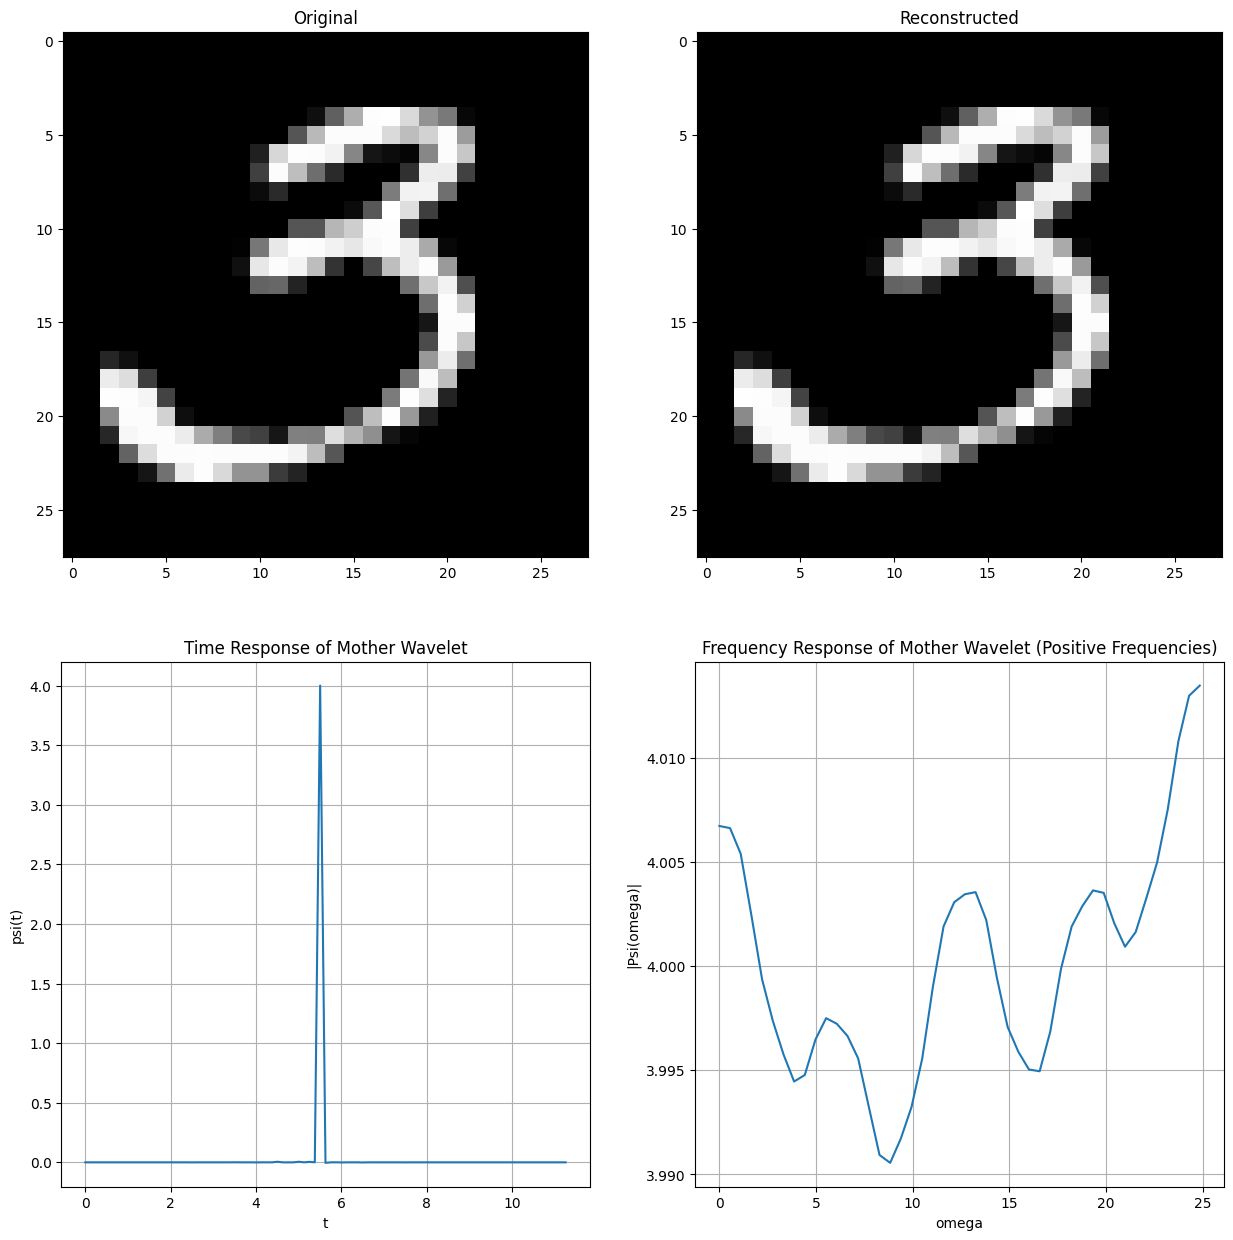

In [ ]:

import matplotlib.pyplot as plt

x, _ = next(iter(train_loader))
x = x[0:1].to(device, dtype=dtype)
coeffs, x_rec = compiled_model(x)

mse = torch.mean(torch.abs(x_rec - x) ** 2)
print(f"MSE: {mse.item():.6f}")

fig, ax = plt.subplots(2, 2, figsize=(15, 15))

ax[0, 0].set_title("Original")
ax[0, 0].imshow(
    x[0, 0].real.cpu().reshape(28, 28).to(torch.float64).detach(), cmap="gray"
)

ax[0, 1].set_title("Reconstructed")
ax[0, 1].imshow(
    x_rec[0, 0].real.cpu().reshape(28, 28).to(torch.float64).detach(), cmap="gray"
)

plot_filters(
    model.params().cpu().detach(),
    axes=(ax[1, 0], ax[1, 1]),
    J=3,
)

plt.show()


In [ ]:
import json

result = {}
for name, value in compiled_model.named_parameters():
    name = name.removeprefix("_orig_mod.")
    result[name] = value.cpu().to(torch.float64).detach().tolist()

print(json.dumps(result, indent=4))

{
    "params.angles": [
        -0.7010962617609392,
        -1.5705390887856328,
        -0.8707976552790646
    ]
}
